<a href="https://colab.research.google.com/github/dagmaros27/AIMS_Notebooks/blob/main/MCMC_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib
%matplotlib inline

import numpy as np
from numpy.linalg import inv
import scipy.linalg as la

import matplotlib.pyplot as plt

Let's start with a 2D example: the TARGET distribution is a 2D Gaussian.
Our distribution willl be of the type: $N(\mathbf{\mu},\mathbf{\Sigma})$
with $\bf{\mu}=(\mu_1=2,\mu_2=3)$ and
$\mathbf{\Sigma} = \left(\begin{matrix} 1 & 0.5 \\ 0.5 & 1 \end{matrix}\right)$
with $|\Sigma|=1-0.25=0.75$.

The multivariate Gaussian takes the famous form:
$$ p(x) = \frac{1}{\sqrt{(2\pi)^2 |\Sigma|}} \exp\left(-\frac{1}{2}(x - \mu)^\dagger \Sigma^{-1} (x - \mu) \right) $$

Just for visualisation purposes, this is how the target distribution look like:

In [2]:
mu=np.array((2,3))
sigma=np.ones(shape=(2,2))
sigma[0,1]=sigma[1,0]=0.5


def Gaussian(x,mu,sigma):
    n=len(x)
    invSig=inv(sigma)
    det=np.linalg.det(sigma)
    return 1./np.sqrt((2*np.pi)**len(x)/det)*np.exp(-0.5*((x-mu).T).dot(invSig.dot(x-mu)))

In [3]:
k=100
grid=np.linspace(0,5,k)
valGauss=np.zeros(shape=(k,k))

for ii, x1 in enumerate(grid):
    for jj, x2 in enumerate(grid):
        valGauss[ii,jj]=Gaussian([x1,x2],mu,sigma)

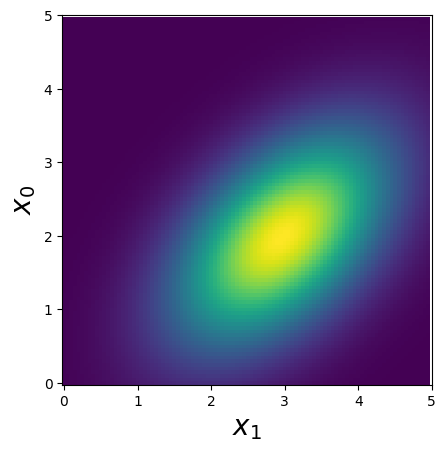

In [4]:
plt.imshow(valGauss,origin='lower',cmap='viridis')
plt.xticks(np.arange(0,6)*int(k/5),[0,1,2,3,4,5])
plt.yticks(np.arange(0,6)*int(k/5),[0,1,2,3,4,5])
plt.ylabel(r'$x_0$', fontsize=20)
plt.xlabel(r'$x_1$', fontsize=20)
plt.show()

Before we go further, a little question, what happen if $\mathbf{\Sigma} = \left(\begin{matrix} 1 & 0 \\ 0 & 1 \end{matrix}\right)$?


and if $\mathbf{\Sigma} = \left(\begin{matrix} 1 & 0.99 \\ 0.99 & 1 \end{matrix}\right)$?


and if $\mathbf{\Sigma} = \left(\begin{matrix} 1 & -0.99 \\ -0.99 & 1 \end{matrix}\right)$?

In [11]:
sigma=np.ones(shape=(2,2))
sigma[0,1]=sigma[1,0]=0

k=100
grid=np.linspace(0,5,k)
valGauss0=np.zeros(shape=(k,k))


for ii, x1 in enumerate(grid):
    for jj, x2 in enumerate(grid):
        valGauss0[ii,jj]=Gaussian([x1,x2],mu,sigma)

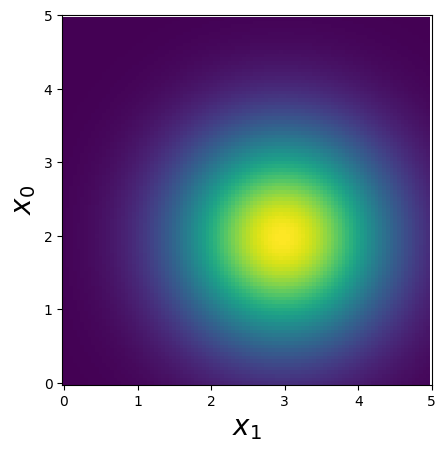

In [12]:
plt.imshow(valGauss0,origin='lower',cmap='viridis')
plt.xticks(np.arange(0,6)*int(k/5),[0,1,2,3,4,5])
plt.yticks(np.arange(0,6)*int(k/5),[0,1,2,3,4,5])
plt.ylabel(r'$x_0$', fontsize=20)
plt.xlabel(r'$x_1$', fontsize=20)
plt.show()

In [13]:
sigma=np.ones(shape=(2,2))
sigma[0,1]=sigma[1,0]=0.99

k=100
grid=np.linspace(0,5,k)
valGauss1=np.zeros(shape=(k,k))


for ii, x1 in enumerate(grid):
    for jj, x2 in enumerate(grid):
        valGauss1[ii,jj]=Gaussian([x1,x2],mu,sigma)

Text(0.5, 0, '$x_1$')

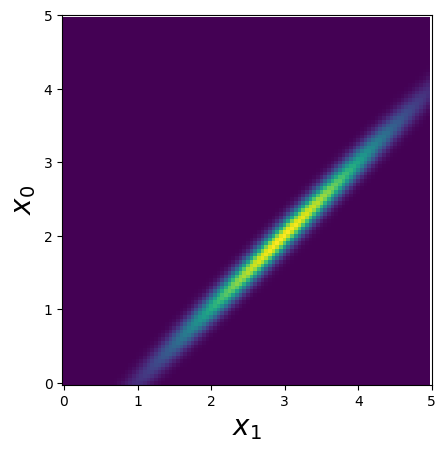

In [14]:
plt.imshow(valGauss1,origin='lower',cmap='viridis')
plt.xticks(np.arange(0,6)*int(k/5),[0,1,2,3,4,5])
plt.yticks(np.arange(0,6)*int(k/5),[0,1,2,3,4,5])
plt.ylabel(r'$x_0$', fontsize=20)
plt.xlabel(r'$x_1$', fontsize=20)

In [15]:
sigma=np.ones(shape=(2,2))
sigma[0,1]=sigma[1,0]=-0.99

k=1000
grid=np.linspace(0,5,k)
valGauss_a=np.zeros(shape=(k,k))


for ii, x1 in enumerate(grid):
    for jj, x2 in enumerate(grid):
        valGauss_a[ii,jj]=Gaussian([x1,x2],mu,sigma)

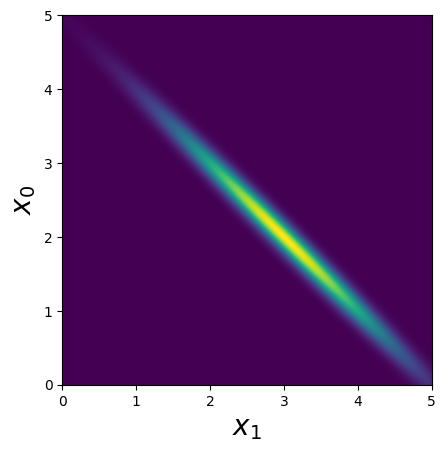

In [16]:
plt.imshow(valGauss_a,origin='lower',cmap='viridis')
plt.xticks(np.arange(0,6)*int(k/5),[0,1,2,3,4,5])
plt.yticks(np.arange(0,6)*int(k/5),[0,1,2,3,4,5])
plt.ylabel(r'$x_0$', fontsize=20)
plt.xlabel(r'$x_1$', fontsize=20)
plt.show()

## Toy MCMC

As we want to learn MCMC, we imagine that evaluating our function on a grid was computationally prohibitive.

We also whould like a fast way to have $p(x_1)=\int(p(x_0,x_1)dx_0$

We explore the Metropolis-Hasting algorithm
The ingredient to get to our target distribution are:
1. a starting point
2. a proposal distribution: as often done in litterature we assume that we can use a 2D Gaussian with covariance matrix Sp
3. a convergence criterium


We also need to be able to draw at every step a new proposed point from the proposal distribution!
How we do that? We have seen during the lessons.

To compute sample vectors from a multivariate Gaussian distribution with zero mean and a given covariance matrix (called Sp in our example), the canonical approach is to compute vectors of the form 𝑦=L𝑧, where L is the Cholesky factor or square root of Sp, and 𝑧 is a standard normal vector.

How to choose Sp? This is not an easy question if we do not have an idea of the shape of our target distribution.


In our case we will start with a diagonal matrix (in this case we do not need Cholesky but we write the generic code to include other matrices).

In [17]:
#the case we would like to analyze:
mu=np.array((2,3))
sigma=np.ones(shape=(2,2))
sigma[0,1]=sigma[1,0]=0.5

k=100
grid=np.linspace(0,5,k)
valGauss_a=np.zeros(shape=(k,k))


for ii, x1 in enumerate(grid):
    for jj, x2 in enumerate(grid):
        valGauss_a[ii,jj]=Gaussian([x1,x2],mu,sigma)

In [18]:
#and the first attempt for the covariance of the proposal matrix, we start with a diagonl one
Sp=np.ones(shape=(2,2))
Sp[0,1]=Sp[1,0]=0

In [19]:
# Cholesky-based sampling
L = np.linalg.cholesky(Sp) #this can be optimized and computed just once

def sample_chol(L):
    n = L.shape[0]
    xi = np.random.randn(n) #using rand lib to draw sample from N(0,I)
    return L.dot(xi)

In [27]:
def next_element(x,L):
    #it takes in input the last point in the chain and the covariance matrix.

    #draw a new potential element for the chain

    y=sample_chol(L)+x

    #evaluate if it is a good draw or not
    ratio=Gaussian(y,mu,sigma)/Gaussian(x,mu,sigma)
    alpha=min(ratio,1)

    #if not accept it with probability alpha
    if (alpha!=1)&(alpha<np.random.uniform()):
        next_el=x
    else: next_el=y

    return next_el

In [28]:
def run_chain(length, x_start, L):
    chain=np.zeros((2,length))
    chain[:,0]=x_start
    for ll in range(1,length):
        chain[:,ll]=next_element(chain[:,ll-1],L) # why Spm changed to L
    return chain

In [29]:
length=100
x_start=[1,1]

chain=run_chain(length, x_start,L)

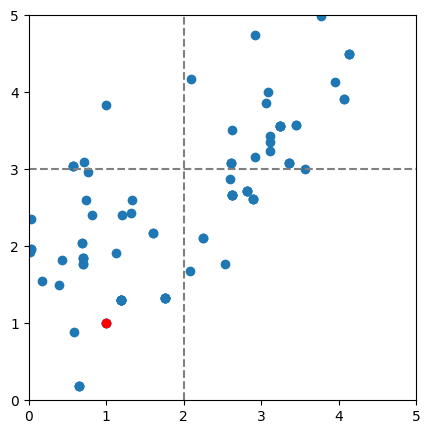

In [30]:
plt.figure(figsize=(5,5))
plt.scatter(chain[0,:],chain[1,:])
plt.scatter(chain[0,0],chain[1,0],c='r')
plt.vlines(2,0,6,color='gray',linestyle='--')
plt.hlines(3,0,6,color='gray',linestyle='--')
plt.xlim(0,5)
plt.ylim(0,5)
plt.show()

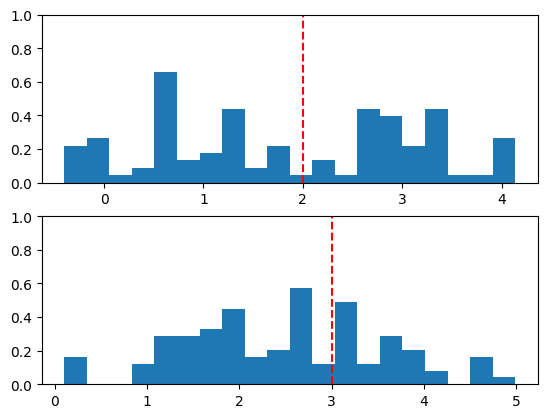

In [31]:
fig, axs = plt.subplots(2)
axs[0].hist(chain[0,:],bins=20, density=True)
axs[0].vlines(mu[0],0,1,color='red',linestyle='--')
axs[0].set_ylim(0,1)

axs[1].hist(chain[1,:],bins=20, density=True)
axs[1].vlines(mu[1],0,1,color='red',linestyle='--')
axs[1].set_ylim(0,1)
plt.show()

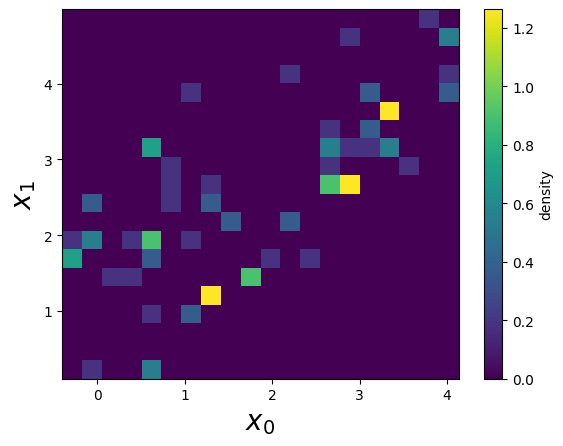

In [33]:
fig, ax = plt.subplots()

h = ax.hist2d(chain[0,:], chain[1,:], bins=20, density=True)

fig.colorbar(h[3], ax=ax, label="density")

ax.set_xlabel(r'$x_0$',fontsize=20)
ax.set_ylabel(r'$x_1$',fontsize=20)

plt.show()

In [34]:
1#2D histogram value
H, xedges, yedges = np.histogram2d(chain[0,:], chain[1,:], bins=20)
xcenters=(xedges[1]-xedges[0])/2.+xedges[:-1]
ycenters=(yedges[1]-yedges[0])/2.+yedges[:-1]
H = H.T

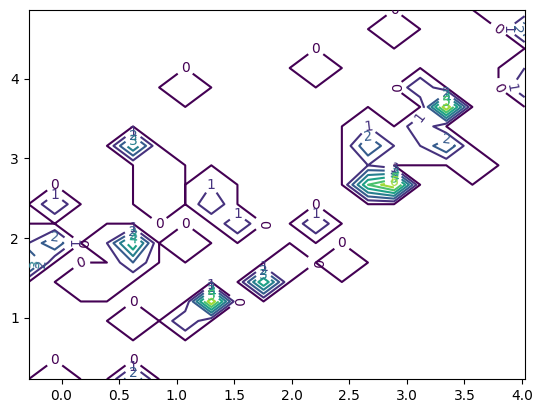

In [35]:
fig, ax = plt.subplots()
CS = ax.contour(xcenters, ycenters, H)
ax.clabel(CS, inline=True, fontsize=10)
plt.show()

In [39]:
print(chain[:, ])

[[ 1.          1.          2.07793239  1.18904284  1.18904284  1.18904284
   1.18904284  1.18904284  1.18904284  1.18904284  0.76264365  1.60311051
   1.60311051  1.33766645  0.73778043  1.20919525  0.02822959  0.58279903
  -0.13118139  0.65269331  0.65269331  0.65269331 -0.3997592   0.7029035
   0.7029035   0.7029035   0.70294539  0.70294539  0.81926502  0.71420241
   0.43026173 -0.25846991 -0.25846991 -0.25846991 -0.25846991  0.57044676
   0.57044676  0.57044676  0.17719078  1.00120259  2.09547261  3.12003445
   2.60536741  2.60536741  2.60536741  3.56846388  3.35916208  3.35916208
   3.35916208  3.95794054  4.13613923  4.13613923  4.13613923  3.7734384
   2.92643949  3.45256459  3.45256459  3.11527323  2.62979758  3.1173261
   2.92675523  3.24733333  3.24733333  3.24733333  3.24733333  3.24733333
   3.09472421  2.89157927  2.89157927  2.89157927  2.53969449  0.69112358
   0.69112358  2.25348507  2.25348507  1.75577859  1.75577859  1.75577859
   1.75577859  1.75577859  1.12298489  0.

In [36]:
cov=np.cov(chain)
print(cov)

[[1.66445108 0.97282071]
 [0.97282071 1.12016349]]


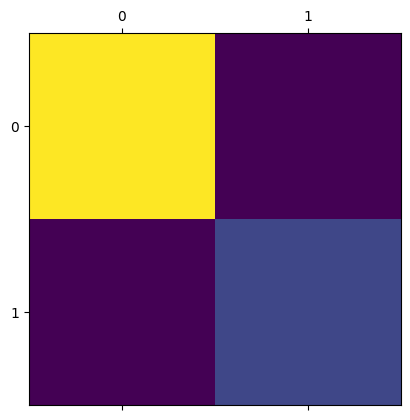

In [37]:
plt.matshow(cov)
plt.show()

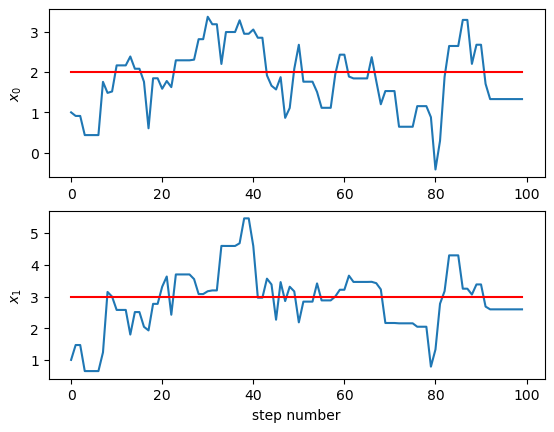

In [ ]:
fig, axs = plt.subplots(2)
axs[0].plot(np.arange(length),chain[0,:])
axs[0].plot(np.arange(length),np.ones(length)*mu[0],color='red')
axs[1].plot(np.arange(length),chain[1,:])
axs[1].plot(np.arange(length),np.ones(length)*mu[1],color='red')
axs[1].set_xlabel("step number")
axs[0].set_ylabel(r'$x_0$')
axs[1].set_ylabel(r'$x_1$')
plt.show()

In [54]:
#Let's try another covariance matrix for the proposal distribution
Sp=np.ones(shape=(2,2))
Sp[0,1]=Sp[1,0]=0.5

In [55]:
L2 = np.linalg.cholesky(Sp)

In [56]:
length=1000
x_start=[1,1]

chain=run_chain(length, x_start,L2)

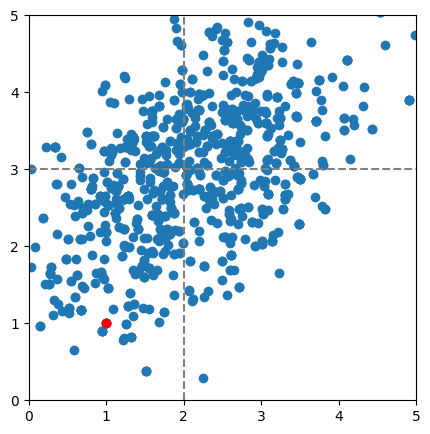

In [57]:
plt.figure(figsize=(5,5))
plt.scatter(chain[0,:],chain[1,:])
plt.scatter(chain[0,0],chain[1,0],c='r')
plt.vlines(2,0,6,color='gray',linestyle='--')
plt.hlines(3,0,6,color='gray',linestyle='--')
plt.xlim(0,5)
plt.ylim(0,5)
plt.show()

In [58]:
burn_in=100
cov=np.cov(chain[:,burn_in:])
print(cov)

[[0.94498268 0.49057374]
 [0.49057374 0.84286872]]


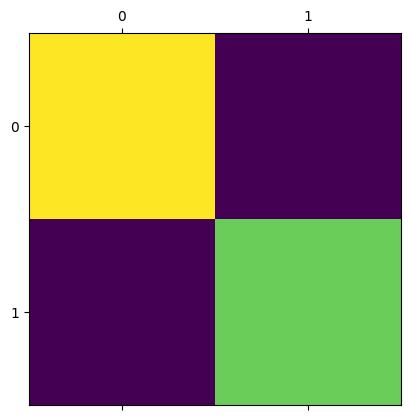

In [59]:
plt.matshow(cov)
plt.show()

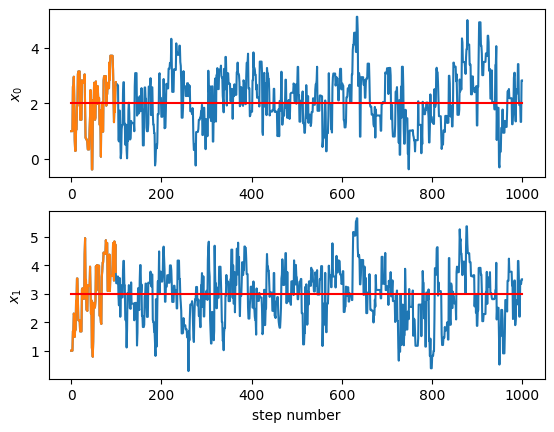

In [60]:
fig, axs = plt.subplots(2)
axs[0].plot(np.arange(length),chain[0,:])
axs[0].plot(np.arange(burn_in),chain[0,:burn_in])
axs[0].plot(np.arange(length),np.ones(length)*mu[0],color='red')
axs[1].plot(np.arange(length),chain[1,:])
axs[1].plot(np.arange(burn_in),chain[1,:burn_in])
axs[1].plot(np.arange(length),np.ones(length)*mu[1],color='red')
axs[1].set_xlabel("step number")
axs[0].set_ylabel(r'$x_0$')
axs[1].set_ylabel(r'$x_1$')
plt.show()